# FASE 6: Clasificacion direccional con SVM (walk-forward)

Objetivo:
- Extender Fase 5 de regresion a clasificacion binaria direccional
- Mantener validacion temporal estricta (expanding window)
- Comparar SVC contra baselines ingenuos obligatorios

Configuracion fija heredada:
- Dataset BVG (event-time, sin forward filling)
- Empresas: CORPORACION FAVORITA C.A. y BANCO GUAYAQUIL S.A.
- Features: lag_1, lag_2, roll_mean_3, roll_mean_5, roll_std_3
- Target clasificacion: 1 si ret_{t+1} > 0, 0 si ret_{t+1} <= 0

Modelos evaluados (sin tuning):
- SVC linear
- SVC rbf
- Baseline 1: clase mayoritaria (en train de cada ventana)
- Baseline 2: signo de ret_t para predecir ret_{t+1}

In [1]:
# 0) Librerias
import importlib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

if importlib.util.find_spec('sklearn') is None:
    print('Instalando scikit-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])

from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Construccion del dataset A (sin imputacion) y target direccional
Se conserva la misma logica de Fase 5 para evitar fuga temporal y cambios de metodologia.

In [2]:
dataset_name = 'beta3/Historical_Data_of_Ecuador_Stock_Exchange'
dataset = load_dataset(dataset_name, 'default_stocks')
df = dataset['stocks'].to_pandas()

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACION' if 'FECHA NEGOCIACION' in df.columns else 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'

df = df[df[emisor_col].isin(empresas_objetivo)].copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[fecha_col, precio_col]).copy()
df = df.sort_values([emisor_col, fecha_col]).reset_index(drop=True)

rows = []
for empresa in empresas_objetivo:
    g = df[df[emisor_col] == empresa].copy()

    # Serie event-time diaria (ultimo trade del dia)
    diario = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
    )

    diario['ret'] = np.log(diario['precio_trade_day'] / diario['precio_trade_day'].shift(1))
    diario = diario.reset_index().rename(columns={fecha_col: 'fecha'})
    diario['empresa'] = empresa

    # Mismas features de Fase 5
    diario['lag_1'] = diario['ret'].shift(1)
    diario['lag_2'] = diario['ret'].shift(2)
    diario['roll_mean_3'] = diario['ret'].rolling(3).mean()
    diario['roll_mean_5'] = diario['ret'].rolling(5).mean()
    diario['roll_std_3'] = diario['ret'].rolling(3).std()

    # Target clasificacion: direccion en t+1
    diario['ret_t1'] = diario['ret'].shift(-1)
    diario['target_cls_t1'] = (diario['ret_t1'] > 0).astype(int)

    # Baseline 2: usar signo de ret_t para predecir ret_{t+1}
    diario['naive_sign_ret_t_pred'] = (diario['ret'] > 0).astype(int)

    rows.append(diario)

df_feat = pd.concat(rows, ignore_index=True)
feature_cols = ['lag_1', 'lag_2', 'roll_mean_3', 'roll_mean_5', 'roll_std_3']
target_col = 'target_cls_t1'

df_model = df_feat.dropna(subset=feature_cols + ['ret', 'ret_t1', target_col]).copy()
df_model = df_model.sort_values(['empresa', 'fecha']).reset_index(drop=True)

print('Shape final modelado clasificacion:', df_model.shape)
print(df_model.groupby('empresa').size().rename('n_samples').to_string())
display(df_model[['fecha', 'empresa', 'ret'] + feature_cols + ['ret_t1', target_col, 'naive_sign_ret_t_pred']].head())

Shape final modelado clasificacion: (2835, 12)
empresa
BANCO GUAYAQUIL S.A.         1150
CORPORACION FAVORITA C.A.    1685


,fecha,empresa,ret,lag_1,lag_2,roll_mean_3,roll_mean_5,roll_std_3,ret_t1,target_cls_t1,naive_sign_ret_t_pred
0,2019-01-18,BANCO GUAYAQUIL S.A.,0.021053,-0.021053,0.000000,-3.932040e-17,-2.359224e-17,0.021053,0.010363,1,1
1,2019-01-23,BANCO GUAYAQUIL S.A.,0.010363,0.021053,-0.021053,3.454262e-03,2.072557e-03,0.021887,0.000000,0,1
2,2019-01-24,BANCO GUAYAQUIL S.A.,0.000000,0.010363,0.021053,1.047207e-02,2.072557e-03,0.010527,0.000000,0,0
3,2019-01-25,BANCO GUAYAQUIL S.A.,0.000000,0.000000,0.010363,3.454262e-03,2.072557e-03,0.005983,-0.010363,0,0
4,2019-01-30,BANCO GUAYAQUIL S.A.,-0.010363,0.000000,0.000000,-3.454262e-03,4.210682e-03,0.005983,0.000000,0,0


## 2. Walk-forward validation (expanding window) para clasificacion
Reglas anti-leakage:
- No random split
- RobustScaler ajustado solo con train en cada ventana
- Baseline mayoritario calculado solo con distribucion de train

In [3]:
def directional_accuracy(y_true, y_pred):
    # En clasificacion direccional binaria, coincide con accuracy de direccion
    return np.mean(y_true == y_pred)

def compute_cls_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'directional_accuracy': directional_accuracy(y_true, y_pred)
    }

def run_walk_forward_svc_with_baselines(
    data_emp,
    feature_cols,
    target_col,
    initial_train_size=300,
    test_size=30,
    step_size=30
):
    data_emp = data_emp.sort_values('fecha').reset_index(drop=True)

    n = len(data_emp)
    if n < (initial_train_size + test_size + 1):
        initial_train_size = max(150, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    rows_metrics = []
    train_end = initial_train_size
    window_id = 0

    while (train_end + test_size) <= n:
        train = data_emp.iloc[:train_end].copy()
        test = data_emp.iloc[train_end:train_end + test_size].copy()

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_test = test[feature_cols].values
        y_test = test[target_col].values

        # Escalado solo con train
        scaler = RobustScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # Modelos SVC sin tuning
        svc_models = {
            'svc_linear': SVC(kernel='linear', C=1.0),
            'svc_rbf': SVC(kernel='rbf', C=1.0, gamma='scale')
        }

        for model_name, model in svc_models.items():
            model.fit(X_train_s, y_train)
            y_pred = model.predict(X_test_s)
            m = compute_cls_metrics(y_test, y_pred)

            rows_metrics.append({
                'window_id': window_id,
                'train_start': train['fecha'].iloc[0],
                'train_end': train['fecha'].iloc[-1],
                'test_start': test['fecha'].iloc[0],
                'test_end': test['fecha'].iloc[-1],
                'n_train': len(train),
                'n_test': len(test),
                'model': model_name,
                **m
            })

        # Baseline 1: clase mayoritaria de train
        majority_class = int(pd.Series(y_train).mode().iloc[0])
        y_pred_majority = np.full(shape=len(y_test), fill_value=majority_class, dtype=int)
        m_majority = compute_cls_metrics(y_test, y_pred_majority)
        rows_metrics.append({
            'window_id': window_id,
            'train_start': train['fecha'].iloc[0],
            'train_end': train['fecha'].iloc[-1],
            'test_start': test['fecha'].iloc[0],
            'test_end': test['fecha'].iloc[-1],
            'n_train': len(train),
            'n_test': len(test),
            'model': 'baseline_majority',
            **m_majority
        })

        # Baseline 2: signo de ret_t
        y_pred_sign = test['naive_sign_ret_t_pred'].values.astype(int)
        m_sign = compute_cls_metrics(y_test, y_pred_sign)
        rows_metrics.append({
            'window_id': window_id,
            'train_start': train['fecha'].iloc[0],
            'train_end': train['fecha'].iloc[-1],
            'test_start': test['fecha'].iloc[0],
            'test_end': test['fecha'].iloc[-1],
            'n_train': len(train),
            'n_test': len(test),
            'model': 'baseline_sign_ret_t',
            **m_sign
        })

        window_id += 1
        train_end += step_size

    return pd.DataFrame(rows_metrics)

## 3. Ejecucion por empresa
Modelos: svc_linear, svc_rbf y dos baselines obligatorios.

In [11]:
wf_cls_all = []

for empresa in empresas_objetivo:
    d_emp = df_model[df_model['empresa'] == empresa].copy()
    print('')
    print('Empresa:', empresa)
    print('n muestras:', len(d_emp))

    res_emp = run_walk_forward_svc_with_baselines(
        data_emp=d_emp,
        feature_cols=feature_cols,
        target_col=target_col,
        initial_train_size=300,
        test_size=30,
        step_size=30
    )

    if res_emp.empty:
        print('- Sin ventanas suficientes')
        continue

    res_emp['empresa'] = empresa
    wf_cls_all.append(res_emp)

    print('- Ventanas evaluadas:', res_emp['window_id'].nunique())
    print('- Modelos por ventana:', sorted(res_emp['model'].unique().tolist()))

wf_cls = pd.concat(wf_cls_all, ignore_index=True)
display(wf_cls)


Empresa: CORPORACION FAVORITA C.A.
n muestras: 1685
- Ventanas evaluadas: 46
- Modelos por ventana: ['baseline_majority', 'baseline_sign_ret_t', 'svc_linear', 'svc_rbf']

Empresa: BANCO GUAYAQUIL S.A.
n muestras: 1150
- Ventanas evaluadas: 28
- Modelos por ventana: ['baseline_majority', 'baseline_sign_ret_t', 'svc_linear', 'svc_rbf']


,window_id,train_start,train_end,test_start,test_end,n_train,n_test,model,accuracy,precision,recall,f1,directional_accuracy,empresa
0,0,2019-01-10,2020-05-06,2020-05-07,2020-06-19,300,30,svc_linear,0.600000,0.000000,0.000000,0.000000,0.600000,CORPORACION FAVORITA C.A.
1,0,2019-01-10,2020-05-06,2020-05-07,2020-06-19,300,30,svc_rbf,0.600000,0.000000,0.000000,0.000000,0.600000,CORPORACION FAVORITA C.A.
2,0,2019-01-10,2020-05-06,2020-05-07,2020-06-19,300,30,baseline_majority,0.600000,0.000000,0.000000,0.000000,0.600000,CORPORACION FAVORITA C.A.
3,0,2019-01-10,2020-05-06,2020-05-07,2020-06-19,300,30,baseline_sign_ret_t,0.366667,0.181818,0.166667,0.173913,0.366667,CORPORACION FAVORITA C.A.
4,1,2019-01-10,2020-06-19,2020-06-22,2020-08-03,330,30,svc_linear,0.700000,0.000000,0.000000,0.000000,0.700000,CORPORACION FAVORITA C.A.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,26,2019-01-18,2025-10-29,2025-10-31,2025-12-18,1080,30,baseline_sign_ret_t,0.333333,0.230769,0.230769,0.230769,0.333333,BANCO GUAYAQUIL S.A.
292,27,2019-01-18,2025-12-18,2025-12-19,2026-02-09,1110,30,svc_linear,0.500000,0.000000,0.000000,0.000000,0.500000,BANCO GUAYAQUIL S.A.
293,27,2019-01-18,2025-12-18,2025-12-19,2026-02-09,1110,30,svc_rbf,0.500000,0.000000,0.000000,0.000000,0.500000,BANCO GUAYAQUIL S.A.
294,27,2019-01-18,2025-12-18,2025-12-19,2026-02-09,1110,30,baseline_majority,0.500000,0.000000,0.000000,0.000000,0.500000,BANCO GUAYAQUIL S.A.


## 4. Metricas por ventana y promedios
Se reportan media y desviacion estandar por empresa y modelo.

In [5]:
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'directional_accuracy']

summary_cls = (
    wf_cls
    .groupby(['empresa', 'model'])
    .agg(
        n_windows=('window_id', 'count'),
        accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
        precision_mean=('precision', 'mean'), precision_std=('precision', 'std'),
        recall_mean=('recall', 'mean'), recall_std=('recall', 'std'),
        f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
        da_mean=('directional_accuracy', 'mean'), da_std=('directional_accuracy', 'std')
    )
    .reset_index()
)

display(summary_cls.sort_values(['empresa', 'f1_mean'], ascending=[True, False]))

,empresa,model,n_windows,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,da_mean,da_std
1,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,28,0.455952,0.113694,0.209216,0.138575,0.210386,0.140017,0.209594,0.138906,0.455952,0.113694
3,BANCO GUAYAQUIL S.A.,svc_rbf,28,0.657143,0.096378,0.296429,0.448439,0.054054,0.110548,0.084115,0.153278,0.657143,0.096378
2,BANCO GUAYAQUIL S.A.,svc_linear,28,0.647619,0.089087,0.035714,0.188982,0.003571,0.018898,0.006494,0.034360,0.647619,0.089087
0,BANCO GUAYAQUIL S.A.,baseline_majority,28,0.646429,0.088582,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.646429,0.088582
7,CORPORACION FAVORITA C.A.,svc_rbf,46,0.680435,0.107399,0.432197,0.413252,0.140711,0.155884,0.196261,0.201635,0.680435,0.107399
5,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,46,0.486232,0.115379,0.184139,0.136727,0.183989,0.137638,0.183871,0.136920,0.486232,0.115379
6,CORPORACION FAVORITA C.A.,svc_linear,46,0.675362,0.094395,0.032609,0.163373,0.015020,0.089180,0.015481,0.083570,0.675362,0.094395
4,CORPORACION FAVORITA C.A.,baseline_majority,46,0.674638,0.094591,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.674638,0.094591


## 5. Comparacion explicita contra baselines
Se calcula diferencia de metricas de cada SVC contra cada baseline.

In [6]:
svc_models = ['svc_linear', 'svc_rbf']
baseline_models = ['baseline_majority', 'baseline_sign_ret_t']

comparison_rows = []

for empresa in empresas_objetivo:
    d = wf_cls[wf_cls['empresa'] == empresa].copy()

    for svc_m in svc_models:
        d_svc = d[d['model'] == svc_m].sort_values('window_id').reset_index(drop=True)

        for base_m in baseline_models:
            d_base = d[d['model'] == base_m].sort_values('window_id').reset_index(drop=True)

            merged = d_svc[['window_id'] + metrics_cols].merge(
                d_base[['window_id'] + metrics_cols],
                on='window_id',
                suffixes=('_svc', '_base')
            )

            if merged.empty:
                continue

            row = {
                'empresa': empresa,
                'svc_model': svc_m,
                'baseline_model': base_m,
                'n_windows': len(merged)
            }

            for m in metrics_cols:
                delta = merged[f'{m}_svc'] - merged[f'{m}_base']
                row[f'delta_{m}_mean'] = float(delta.mean())
                row[f'delta_{m}_std'] = float(delta.std(ddof=1)) if len(delta) > 1 else 0.0
                row[f'pct_windows_{m}_better'] = float((delta > 0).mean() * 100)

            comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(['empresa', 'svc_model', 'baseline_model']))

,empresa,svc_model,baseline_model,n_windows,delta_accuracy_mean,delta_accuracy_std,pct_windows_accuracy_better,delta_precision_mean,delta_precision_std,pct_windows_precision_better,delta_recall_mean,delta_recall_std,pct_windows_recall_better,delta_f1_mean,delta_f1_std,pct_windows_f1_better,delta_directional_accuracy_mean,delta_directional_accuracy_std,pct_windows_directional_accuracy_better
4,BANCO GUAYAQUIL S.A.,svc_linear,baseline_majority,28,0.001190,0.006299,3.571429,0.035714,0.188982,3.571429,0.003571,0.018898,3.571429,0.006494,0.034360,3.571429,0.001190,0.006299,3.571429
5,BANCO GUAYAQUIL S.A.,svc_linear,baseline_sign_ret_t,28,0.191667,0.082962,96.428571,-0.173501,0.235796,3.571429,-0.206814,0.141559,0.000000,-0.203101,0.143543,0.000000,0.191667,0.082962,96.428571
6,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_majority,28,0.010714,0.031497,28.571429,0.296429,0.448439,32.142857,0.054054,0.110548,32.142857,0.084115,0.153278,32.142857,0.010714,0.031497,28.571429
7,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_sign_ret_t,28,0.201190,0.093175,96.428571,0.087213,0.472454,32.142857,-0.156332,0.190460,7.142857,-0.125480,0.219151,14.285714,0.201190,0.093175,96.428571
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_majority,46,0.000725,0.004915,2.173913,0.032609,0.163373,4.347826,0.015020,0.089180,4.347826,0.015481,0.083570,4.347826,0.000725,0.004915,2.173913
1,CORPORACION FAVORITA C.A.,svc_linear,baseline_sign_ret_t,46,0.189130,0.071338,100.000000,-0.151530,0.181699,4.347826,-0.168969,0.159302,2.173913,-0.168390,0.152758,2.173913,0.189130,0.071338,100.000000
2,CORPORACION FAVORITA C.A.,svc_rbf,baseline_majority,46,0.005797,0.062580,36.956522,0.432197,0.413252,60.869565,0.140711,0.155884,60.869565,0.196261,0.201635,60.869565,0.005797,0.062580,36.956522
3,CORPORACION FAVORITA C.A.,svc_rbf,baseline_sign_ret_t,46,0.194203,0.095918,97.826087,0.248058,0.425487,54.347826,-0.043278,0.190024,21.739130,0.012390,0.226492,36.956522,0.194203,0.095918,97.826087


In [7]:
# Tabla resumen final por empresa
final_rows = []

for empresa in empresas_objetivo:
    s = summary_cls[summary_cls['empresa'] == empresa].copy()

    best_model = s.sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]

    # Mejor baseline segun f1 medio
    sb = s[s['model'].isin(baseline_models)].sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]

    final_rows.append({
        'empresa': empresa,
        'best_model': best_model['model'],
        'best_model_f1_mean': best_model['f1_mean'],
        'best_model_acc_mean': best_model['accuracy_mean'],
        'best_model_da_mean': best_model['da_mean'],
        'best_model_f1_std': best_model['f1_std'],
        'best_model_acc_std': best_model['accuracy_std'],
        'best_baseline': sb['model'],
        'best_baseline_f1_mean': sb['f1_mean'],
        'best_baseline_acc_mean': sb['accuracy_mean'],
        'delta_f1_vs_best_baseline': best_model['f1_mean'] - sb['f1_mean'],
        'delta_acc_vs_best_baseline': best_model['accuracy_mean'] - sb['accuracy_mean']
    })

final_summary_df = pd.DataFrame(final_rows)
display(final_summary_df)

,empresa,best_model,best_model_f1_mean,best_model_acc_mean,best_model_da_mean,best_model_f1_std,best_model_acc_std,best_baseline,best_baseline_f1_mean,best_baseline_acc_mean,delta_f1_vs_best_baseline,delta_acc_vs_best_baseline
0,CORPORACION FAVORITA C.A.,svc_rbf,0.196261,0.680435,0.680435,0.201635,0.107399,baseline_sign_ret_t,0.183871,0.486232,0.01239,0.194203
1,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,0.209594,0.455952,0.455952,0.138906,0.113694,baseline_sign_ret_t,0.209594,0.455952,0.00000,0.000000


## 6. Visualizacion de estabilidad por ventana
Se inspecciona estabilidad temporal de accuracy, f1 y directional accuracy.

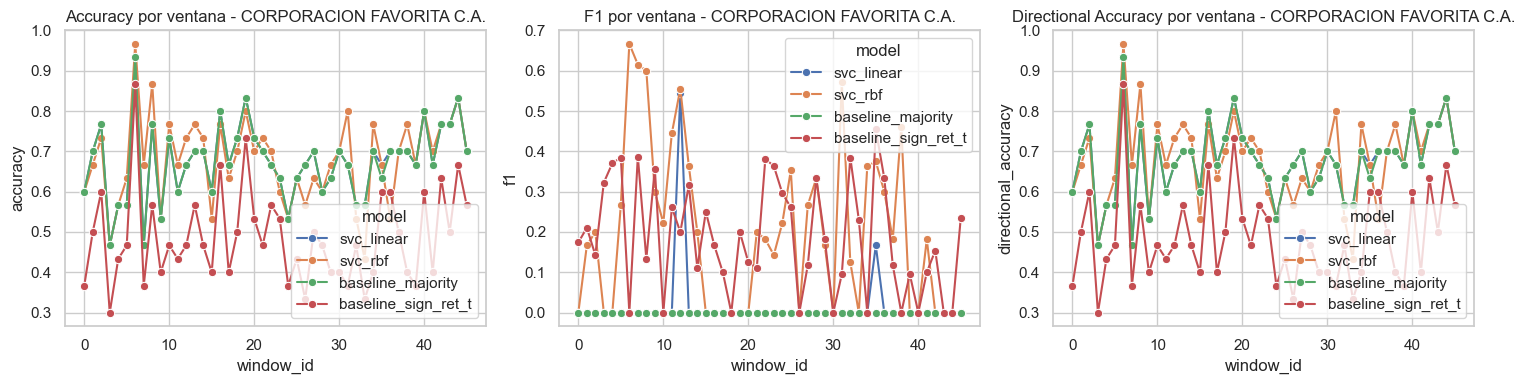

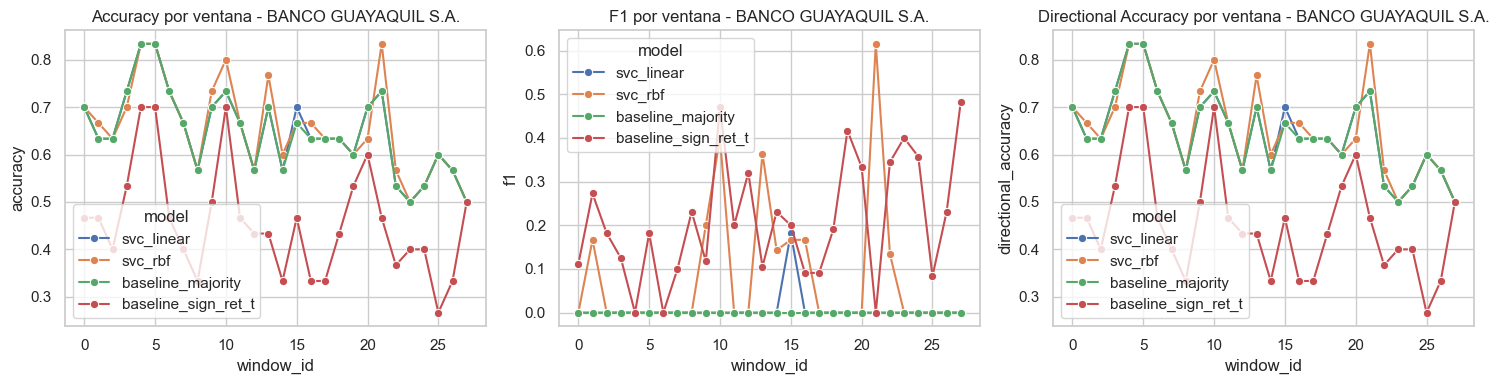

In [8]:
plot_models = ['svc_linear', 'svc_rbf', 'baseline_majority', 'baseline_sign_ret_t']

for empresa in empresas_objetivo:
    d = wf_cls[(wf_cls['empresa'] == empresa) & (wf_cls['model'].isin(plot_models))].copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.lineplot(data=d, x='window_id', y='accuracy', hue='model', marker='o', ax=axes[0])
    axes[0].set_title('Accuracy por ventana - {}'.format(empresa))

    sns.lineplot(data=d, x='window_id', y='f1', hue='model', marker='o', ax=axes[1])
    axes[1].set_title('F1 por ventana - {}'.format(empresa))

    sns.lineplot(data=d, x='window_id', y='directional_accuracy', hue='model', marker='o', ax=axes[2])
    axes[2].set_title('Directional Accuracy por ventana - {}'.format(empresa))

    plt.tight_layout()
    plt.show()

## 7. Analisis critico automatico (basado solo en resultados numericos)
Responde explicitamente las 5 preguntas obligatorias con criterios cuantitativos.

In [9]:
print('=== ANALISIS CRITICO FASE 6 (SVM CLASIFICACION DIRECCIONAL) ===')

for empresa in empresas_objetivo:
    s = summary_cls[summary_cls['empresa'] == empresa].copy()
    s_svc = s[s['model'].isin(['svc_linear', 'svc_rbf'])].copy()
    s_base = s[s['model'].isin(['baseline_majority', 'baseline_sign_ret_t'])].copy()

    best_svc = s_svc.sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]
    best_base = s_base.sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]

    # Comparacion por ventanas contra mejor baseline
    w_svc = wf_cls[(wf_cls['empresa'] == empresa) & (wf_cls['model'] == best_svc['model'])].sort_values('window_id')
    w_base = wf_cls[(wf_cls['empresa'] == empresa) & (wf_cls['model'] == best_base['model'])].sort_values('window_id')
    wb = w_svc[['window_id', 'accuracy', 'f1', 'directional_accuracy']].merge(
        w_base[['window_id', 'accuracy', 'f1', 'directional_accuracy']],
        on='window_id', suffixes=('_svc', '_base')
    )

    pct_win_acc_better = float(((wb['accuracy_svc'] - wb['accuracy_base']) > 0).mean() * 100)
    pct_win_f1_better = float(((wb['f1_svc'] - wb['f1_base']) > 0).mean() * 100)

    # 1) Supera baseline consistentemente?
    supera_consistente = (pct_win_acc_better >= 60.0) and (pct_win_f1_better >= 60.0)

    # 2) Estabilidad
    estable = (best_svc['accuracy_std'] <= 0.10) and (best_svc['f1_std'] <= 0.10)

    # 3) Evidencia de senal direccional
    # Criterio conservador: mejora sobre mejor baseline y accuracy media > 0.50
    delta_acc = float(best_svc['accuracy_mean'] - best_base['accuracy_mean'])
    delta_f1 = float(best_svc['f1_mean'] - best_base['f1_mean'])
    hay_senal = (delta_acc > 0.0) and (delta_f1 > 0.0) and (best_svc['accuracy_mean'] > 0.50)

    # 4) Mejor kernel
    kernel_mejor = best_svc['model']

    # 5) Justifica tuning
    justificar_tuning = supera_consistente and estable and hay_senal

    print('')
    print('Empresa: {}'.format(empresa))
    print('Modelos (media/std):')
    print(s[['model', 'n_windows', 'accuracy_mean', 'accuracy_std', 'precision_mean', 'recall_mean', 'f1_mean', 'f1_std', 'da_mean', 'da_std']].sort_values('f1_mean', ascending=False).to_string(index=False))

    print('Respuestas obligatorias:')
    print('1) Supera consistentemente al baseline?: {}'.format('SI' if supera_consistente else 'NO'))
    print('   - Mejor SVC: {} | Mejor baseline: {}'.format(best_svc['model'], best_base['model']))
    print('   - % ventanas con mejora en accuracy: {:.2f}%'.format(pct_win_acc_better))
    print('   - % ventanas con mejora en f1: {:.2f}%'.format(pct_win_f1_better))

    print('2) Que tan estable es el desempeno?: {}'.format('ESTABLE' if estable else 'INESTABLE'))
    print('   - accuracy_std={:.4f}, f1_std={:.4f}'.format(best_svc['accuracy_std'], best_svc['f1_std']))

    print('3) Hay evidencia de senal direccional real?: {}'.format('SI' if hay_senal else 'NO / DEBIL'))
    print('   - delta_acc_vs_best_baseline={:.4f}, delta_f1_vs_best_baseline={:.4f}'.format(delta_acc, delta_f1))

    print('4) Que kernel funciona mejor?: {}'.format(kernel_mejor))
    print('   - f1_mean={:.4f}, accuracy_mean={:.4f}, da_mean={:.4f}'.format(best_svc['f1_mean'], best_svc['accuracy_mean'], best_svc['da_mean']))

    print('5) Se justifica pasar a tuning?: {}'.format('SI' if justificar_tuning else 'NO'))
    if not justificar_tuning:
        print('   - Motivo cuantitativo: falta de superioridad consistente y/o inestabilidad y/o senal debil.')

=== ANALISIS CRITICO FASE 6 (SVM CLASIFICACION DIRECCIONAL) ===

Empresa: CORPORACION FAVORITA C.A.
Modelos (media/std):
              model  n_windows  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean   f1_std  da_mean   da_std
            svc_rbf         46       0.680435      0.107399        0.432197     0.140711 0.196261 0.201635 0.680435 0.107399
baseline_sign_ret_t         46       0.486232      0.115379        0.184139     0.183989 0.183871 0.136920 0.486232 0.115379
         svc_linear         46       0.675362      0.094395        0.032609     0.015020 0.015481 0.083570 0.675362 0.094395
  baseline_majority         46       0.674638      0.094591        0.000000     0.000000 0.000000 0.000000 0.674638 0.094591
Respuestas obligatorias:
1) Supera consistentemente al baseline?: NO
   - Mejor SVC: svc_rbf | Mejor baseline: baseline_sign_ret_t
   - % ventanas con mejora en accuracy: 97.83%
   - % ventanas con mejora en f1: 36.96%
2) Que tan estable es el desempeno?

In [10]:
# Resumen final compacto solicitado
print('=== TABLA RESUMEN FINAL POR EMPRESA ===')
print(final_summary_df.to_string(index=False))

print('\n=== COMPARACION EXPLICITA SVC VS BASELINES ===')
cols_show = [
    'empresa', 'svc_model', 'baseline_model', 'n_windows',
    'delta_accuracy_mean', 'delta_precision_mean', 'delta_recall_mean', 'delta_f1_mean', 'delta_directional_accuracy_mean',
    'pct_windows_accuracy_better', 'pct_windows_f1_better', 'pct_windows_directional_accuracy_better'
]
print(comparison_df[cols_show].sort_values(['empresa', 'svc_model', 'baseline_model']).to_string(index=False))

=== TABLA RESUMEN FINAL POR EMPRESA ===
                  empresa          best_model  best_model_f1_mean  best_model_acc_mean  best_model_da_mean  best_model_f1_std  best_model_acc_std       best_baseline  best_baseline_f1_mean  best_baseline_acc_mean  delta_f1_vs_best_baseline  delta_acc_vs_best_baseline
CORPORACION FAVORITA C.A.             svc_rbf            0.196261             0.680435            0.680435           0.201635            0.107399 baseline_sign_ret_t               0.183871                0.486232                    0.01239                    0.194203
     BANCO GUAYAQUIL S.A. baseline_sign_ret_t            0.209594             0.455952            0.455952           0.138906            0.113694 baseline_sign_ret_t               0.209594                0.455952                    0.00000                    0.000000

=== COMPARACION EXPLICITA SVC VS BASELINES ===
                  empresa  svc_model      baseline_model  n_windows  delta_accuracy_mean  delta_precision_me